# Proyecto Integrador
## Limpieza, validación, groupby, concat y visualización de datos
**Diplomado en Analítica de Datos con Python**  
**Dataset:** Cleaning Practice with Errors & Missing Values – Kaggle  
**Estudiante:** Karina Correa  
**Profesor:** Juan Montenegro, M.Sc

### Parte 1. Carga y exploración inicial

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

ruta = "data_cleaning_practice_dataset.csv"
df_original = pd.read_csv(ruta)
df = df_original.copy()

In [2]:
print("Primeras filas")
print("=" * 45)
print(df.head())

print("\nFilas y columnas")
print("=" * 45)
print(df.shape)

print("\nINFO")
print("=" * 45)
print(df.info())

print("\nEstadistica_básica")
print("=" * 45)
print(df.describe(include="all"))

print("\nColumnas con formato")
print("=" * 45)
for col in df.columns:
    print(f"'{col}'")

print("\nTipo de datos")
print(df.dtypes)

Primeras filas
     Name  Gender   Age     City Department     Salary               Email
0   Tariq    Male  47.0  Karachi     Sales   123609.72   tariq76@gmail.com
1    Hina  Female  26.0   Quetta         HR  125683.94    hina90@gmail.com
2   Usman    Male  36.0   lahore     Sales         NaN   usman71@gmail.com
3    Sana  Female  21.0   Quetta    Finance  147901.41    sana72@gmail.com
4  Ayesha    Male  40.0   lahore         HR  123880.80  ayesha25@gmail.com

Filas y columnas
(500, 7)

INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        500 non-null    object 
 1   Gender      500 non-null    object 
 2   Age         252 non-null    float64
 3   City        500 non-null    object 
 4   Department  500 non-null    object 
 5   Salary      248 non-null    float64
 6   Email       500 non-null    object 
dtypes: float64(2), object(5)

### **Preguntas**
- ¿Cuántas filas y columnas tiene el dataset?
   - 500 filas y 7 columnas
- ¿Qué columnas parecen numéricas?
   - Age , Salary
- ¿Qué columnas parecen categóricas?
   - Name, Gender, City, Department, Email.
- ¿Hay columnas con nombres poco claros o espacios?
   - No, los nombres son claros y no presentan espacios.
- ¿El dataset parece listo para analizar?
  - No, porque hay valores faltantes en las columnas age y salary.

### Parte 2. Auditoría de calidad de datos

Antes de limpiar, cuantifique los problemas. El objetivo es crear evidencia.

In [3]:
# Nulos por columna
nulos = df.isna().sum().sort_values(ascending=False)
porcentaje_nulos = (df.isna().mean() * 100).sort_values(ascending=False)
reporte_nulos = pd.DataFrame({"nulos": nulos, "porcentaje": porcentaje_nulos.round(2)})
print("=== Nulos por columna ===")
print(reporte_nulos.head(10))

# Duplicados exactos
duplicados_exactos = df.duplicated().sum()
print("\n=== Duplicados Exactos ===")
print(duplicados_exactos)

# Cantidad de valores únicos por columna
print("\n===Valores únicos por columna===")
print(df.nunique(dropna=False).sort_values())

=== Nulos por columna ===
            nulos  porcentaje
Salary        252        50.4
Age           248        49.6
Name            0         0.0
Gender          0         0.0
City            0         0.0
Department      0         0.0
Email           0         0.0

=== Duplicados Exactos ===
0

===Valores únicos por columna===
Gender          2
Name           10
City           10
Department     10
Age            42
Salary        249
Email         408
dtype: int64


### Completar una bitácora de calidad de datos

In [4]:
# Bitácora de calidad de datos
bitacora = pd.DataFrame([
    {"Columna": "Salary", "Problema detectado": "Nulos",
        "Evidencia": "252 nulos (50.4%)", "Decisión propuesta": "Se conservan los NaN"},
    {"Columna": "Age",    "Problema detectado": "Nulos",
        "Evidencia": "248 nulos (49.6%)", "Decisión propuesta": "Se conservan los NaN"},
    {"Columna": "Gender", "Problema detectado": "Texto inconsistente", "Evidencia": "2 valores únicos, posible mezcla de mayúsculas",
     "Decisión propuesta": "Estandarizar"},
    {"Columna": "Name",   "Problema detectado": "Texto inconsistente", "Evidencia": "10 valores únicos, posible mezcla de mayúsculas",
     "Decisión propuesta": "Estandarizar"},
    {"Columna": "City", "Problema detectado": "Texto inconsistente", "Evidencia": "Mezcla de mayúsculas: 'lahore', 'Karachi', 'QUETTA'",
        "Decisión propuesta": "Estandarizar con str.strip().str.lower()"},
    {"Columna": "Department", "Problema detectado": "Texto inconsistente",
        "Evidencia": "Posibles variantes de capitalización entre registros", "Decisión propuesta": "Estandarizar con str.strip().str.lower()"},
])
bitacora

,Columna,Problema detectado,Evidencia,Decisión propuesta
0,Salary,Nulos,252 nulos (50.4%),Se conservan los NaN
1,Age,Nulos,248 nulos (49.6%),Se conservan los NaN
2,Gender,Texto inconsistente,"2 valores únicos, posible mezcla de mayúsculas",Estandarizar
3,Name,Texto inconsistente,"10 valores únicos, posible mezcla de mayúsculas",Estandarizar
4,City,Texto inconsistente,"Mezcla de mayúsculas: 'lahore', 'Karachi', 'QU...",Estandarizar con str.strip().str.lower()
5,Department,Texto inconsistente,Posibles variantes de capitalización entre reg...,Estandarizar con str.strip().str.lower()


### Parte 3. Limpieza del dataset

- Aplique una limpieza reproducible. Ajuste el código según las columnas reales del dataset.
- Importante: no todas las columnas con nulos deben imputarse.
- Algunas pueden representar información no registrada o no aplicable.


In [5]:
# Parte 3. Limpieza del dataset

# 1. Limpiar nombres de columnas
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

# 2. Limpiar columnas de texto
columnas_texto = df.select_dtypes(include=["object", "string"]).columns
for col in columnas_texto:
    df[col] = df[col].astype("string").str.strip().str.lower()

# 3. Eliminar duplicados exactos
df = df.drop_duplicates()

# 4. Convertir columnas numéricas que hayan quedado como texto
for col in df.columns:
    if df[col].dtype in ["object", "string"]:
        posible_num = pd.to_numeric(
            df[col].str.replace(",", "", regex=False),
            errors="coerce"
        )
        proporcion_convertible = posible_num.notna().mean()
        if proporcion_convertible >= 0.70:
            df[col] = posible_num
            print(f"{col}: convertida a numérico")
        else:
            print(f"{col}: conservada como texto (proporción convertible: {proporcion_convertible:.2%})")

name: conservada como texto (proporción convertible: 0.00%)
gender: conservada como texto (proporción convertible: 0.00%)
city: conservada como texto (proporción convertible: 0.00%)
department: conservada como texto (proporción convertible: 0.00%)
email: conservada como texto (proporción convertible: 0.00%)


In [6]:
print("Columnas limpias:")
print(df.columns)

print("\nTipos de datos:")
print(df.dtypes)

print("\nPrimeras filas:")
print(df.head())

print("\nFilas y columnas:")
print(df.shape)

Columnas limpias:
Index(['name', 'gender', 'age', 'city', 'department', 'salary', 'email'], dtype='object')

Tipos de datos:
name          string[python]
gender        string[python]
age                  float64
city          string[python]
department    string[python]
salary               float64
email         string[python]
dtype: object

Primeras filas:
     name  gender   age     city department     salary               email
0   tariq    male  47.0  karachi      sales  123609.72   tariq76@gmail.com
1    hina  female  26.0   quetta         hr  125683.94    hina90@gmail.com
2   usman    male  36.0   lahore      sales        NaN   usman71@gmail.com
3    sana  female  21.0   quetta    finance  147901.41    sana72@gmail.com
4  ayesha    male  40.0   lahore         hr  123880.80  ayesha25@gmail.com

Filas y columnas:
(500, 7)


In [7]:
# Decisión sobre nulos en Age y Salary
# Age: 248 nulos (49.6%) | Salary: 252 nulos (50.4%)
# Con ~50% de datos faltantes, imputar con mediana distorsionaría la distribución.
# Se conservan los NaN.

print("Nulos conservados intencionalmente:")
print(df[["age", "salary"]].isna().sum())
print("\nJustificación: porcentaje > 40% hace inviable la imputación sin sesgar el análisis.")

Nulos conservados intencionalmente:
age       248
salary    252
dtype: int64

Justificación: porcentaje > 40% hace inviable la imputación sin sesgar el análisis.


### Parte 4. Práctica obligatoria con concatenate: pd.concat()
- Aunque Kaggle entregue un solo CSV, simule que el archivo llegó dividido en dos lotes.
- Luego reconstruya el dataset usando pd.concat().

In [8]:
# Simular dos lotes del mismo dataset
mitad = len(df_original) // 2
lote_1 = df_original.iloc[:mitad].copy()
lote_2 = df_original.iloc[mitad:].copy()
print(lote_1.shape)
print(lote_2.shape)

# Concatenar los lotes
reconstruido = pd.concat([lote_1, lote_2], ignore_index=True)
print("Original:", df_original.shape)
print("Reconstruido:", reconstruido.shape)

# Validación de filas y columnas
assert reconstruido.shape[0] == df_original.shape[0]
assert reconstruido.shape[1] == df_original.shape[1]

(250, 7)
(250, 7)
Original: (500, 7)
Reconstruido: (500, 7)


### Responda:
- ¿Por qué en este caso usamos concat() y no merge()?
  - Porque los dos lotes son fragmentos del mismo dataset con las mismas columnas.
  - concat() apila filas.
  - merge() se usa para unir tablas distintas por una columna clave.
- ¿Qué significa ignore_index=True?
  - Reinicia el índice desde 0, evitando índices duplicados entre los dos lotes.
- ¿Cómo comprobó que la concatenación no perdió filas?
   - Con assert reconstruido.shape[0] == df_original.shape[0]:
   - si falla lanza un error; si pasa, la cuenta de filas es idéntica.
- ¿Qué podría salir mal si los dos lotes no tienen las mismas columnas?
   - pd.concat() inserta NaN donde una columna existe en un lote pero no en el otro, rompiendo la integridad del dataset.

### Validación adicional:

In [9]:
# Validar si ambos lotes tienen las mismas columnas
mismas_columnas = list(lote_1.columns) == list(lote_2.columns)
print(mismas_columnas)

# Ver columnas que no coinciden, si aplica
set(lote_1.columns).symmetric_difference(set(lote_2.columns))

True


set()

### Parte 5. Práctica obligatoria con groupby()

-Use groupby() para resumir el dataset limpio. 
- Como los nombres de columnas pueden variar, primero identifique:
  - columnas categóricas y numéricas.

In [10]:
# Identificar columnas disponibles después de limpiar
categoricas = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numericas = df.select_dtypes(include=["number"]).columns.tolist()
print("Categóricas:", categoricas)
print("Numéricas:", numericas)

Categóricas: ['name', 'gender', 'city', 'department', 'email']
Numéricas: ['age', 'salary']


In [11]:
# Seleccione una columna categórica y una numérica para el análisis
cat_col = "department"
num_col = "salary"

# Conteo por categoría
conteo_categoria = (df.groupby(cat_col).size().sort_values(ascending=False))
conteo_categoria.head(10)

department
hr           115
it           106
finance       96
sales         94
marketing     89
dtype: int64

In [12]:
# Resumen de variable numérica por categoría
resumen_groupby = (df.groupby(cat_col)[num_col].agg(["count", "mean", "median", "min", "max"])
                   .sort_values("count", ascending=False))

resumen_groupby.head(10)

,count,mean,median,min,max
department,,,,,
it,54,91168.057778,95856.465,26632.99,149944.07
marketing,51,90808.302745,97298.180,26048.44,147469.78
hr,51,95084.349804,99667.070,27689.13,149978.29
finance,46,88747.208478,86704.780,25041.66,147997.25
sales,46,85195.420217,88162.480,27972.01,149798.36


### Análisis con groupby() Resultado esperado

- **Conteo por categoria:** Top 10 categorías con más registros 
- **Promedio (mean) por categoria:** Comparación de una variable numérica entre categorías
- **Mediana (median) por categoria:** Resumen menos sensible a outliers 
- **Mínimo y máximo:** Detección de rangos sospechosos

### 5. Requisitos de gráficos
- Cada estudiante debe crear mínimo cuatro gráficos. 
- Cada gráfico debe tener título, ejes legibles y una interpretación breve de 2 a 3 líneas.

#### Gráfico 1: top 10 columnas con más nulos
- Visualizar el problema de datos faltantes
- Código sugerido: reporte_nulos.head(10)["porcentaje"].plot(kind="barh")

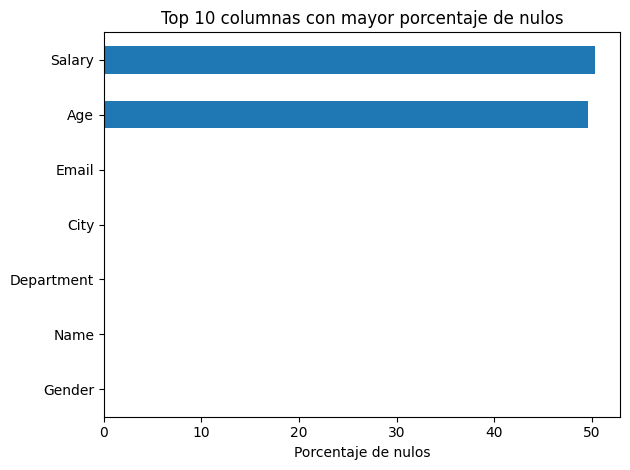

In [13]:
# Gráfico 1: top 10 columnas con más nulos
ax = reporte_nulos.head(10)["porcentaje"].sort_values().plot(kind="barh")
ax.set_title("Top 10 columnas con mayor porcentaje de nulos")
ax.set_xlabel("Porcentaje de nulos")
plt.tight_layout()
plt.show()

**Interpretación — Gráfico 1:**
- El gráfico muestra que, dentro de las 10 columnas analizadas, solo “Salary” y “Age” presentan un porcentaje significativo de valores nulos (aproximadamente 50%).
- Las demás columnas (“Email”, “Department”, “City”, “Gender” y “Name”) no tienen valores faltantes visibles.
- Con un porcentaje tan alto de nulos en ambas variables numéricas, se decidió conservar los NaN en lugar de imputar, ya que imputar con mediana distorsionaría artificialmente la distribución y sesgaría cualquier análisis posterior.

#### Gráfico 2: distribución de una variable numérica
- Detectar asimetría y posibles outliers
- df[num_col].plot(kind="hist", bins=20)

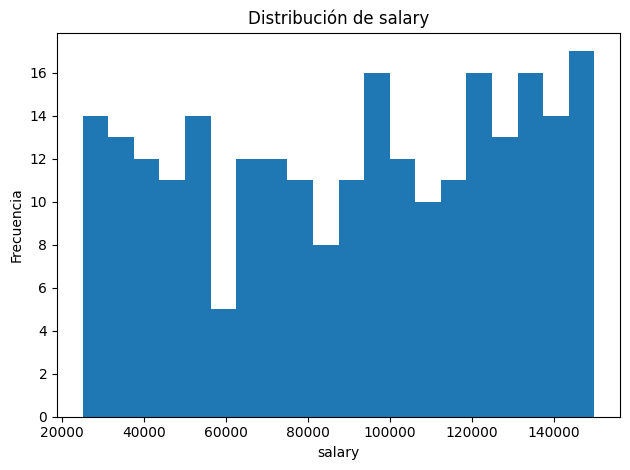

In [14]:
# Gráfico 2: distribución de una variable numérica
df[num_col].plot(kind="hist", bins=20)
plt.title(f"Distribución de {num_col}")
plt.xlabel(num_col)
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

**Interpretación — Gráfico 2:**
- El histograma muestra que los salarios del dataset se distribuyen en un rango amplio, entre aproximadamente 20 000 y 140 000.
- La mayoría de los colaboradores se concentran en el rango salarial de 80 000 a 100 000.
- Hay registros de salarios más bajos cercanos a 30, 000 y más altos superiores a 140 000 con menor frecuencia.
- la distribución de los salarios es moderadamente uniforme.

#### Gráfico 3: conteo por categoría
- Comparar categorías principales
- conteo_categoria.head(10).plot(kind="bar")

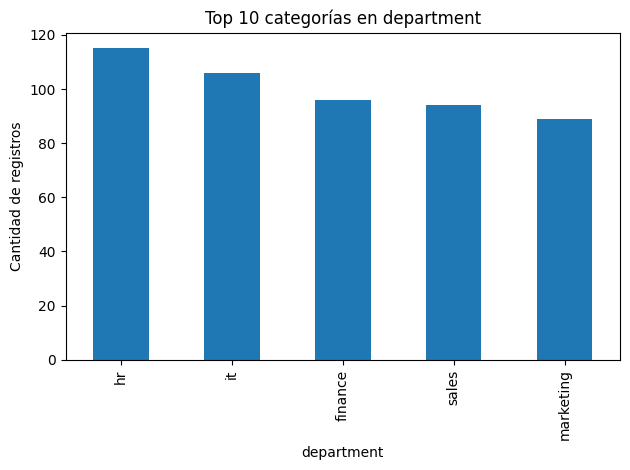

In [15]:
# Gráfico 3: conteo por categoría
conteo_categoria.head(10).plot(kind="bar")
plt.title(f"Top 10 categorías en {cat_col}")
plt.xlabel(cat_col)
plt.ylabel("Cantidad de registros")
plt.tight_layout()
plt.show()

**Interpretación — Gráfico 3:**  
- El gráfico de barras muestra la frecuencia de registros por departamento. 
- El departamento con más cantidad de resgistros es el "RH" con más de 115 registros.
- El departamento de marketing es el menos frecuente, con aproximadamente 85 registros.
- La frecuencia de registros está dentro del rango de 85-115 registros 

#### Gráfico 4: Promedio de salario por departamento
- Comunicar el resumen por objetivo
- resumen_groupby["mean"]

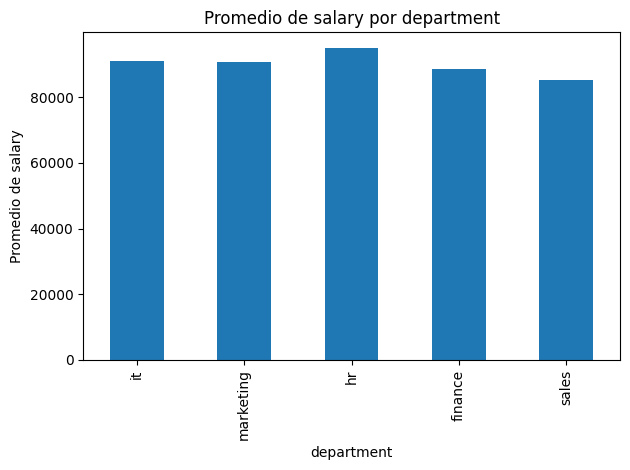

In [16]:
# Gráfico 4: promedio por categoría usando groupby
resumen_groupby["mean"].head(10).plot(kind="bar")
plt.title(f"Promedio de {num_col} por {cat_col}")
plt.xlabel(cat_col)
plt.ylabel(f"Promedio de {num_col}")
plt.tight_layout()
plt.show()

**Interpretación — Gráfico 4:**  
- Compara los salarios promedio asociados a cada categoria de la columna "departament"
- El departamento de "hr" tiene el promedio salarial más alto.
- El departamento de "ventas" tiene el salario promedio más bajo.
- En general, los salarios promedio entre departamentos se encuentran en rangos cercanos.

#### PARTE 6 Validación del dataset limpio
- Compare el dataset antes y después de limpiar. 
- El objetivo es demostrar que las decisiones fueron controladas.

In [17]:
print("Filas originales:", df_original.shape[0])
print("Filas finales:", df.shape[0])
print("Columnas originales:", df_original.shape[1])
print("Columnas finales:", df.shape[1])
print("Duplicados finales:", df.duplicated().sum())
print("Nulos finales por columna:")
print(df.isna().sum().sort_values(ascending=False).head(10))
# Validaciones básicas
assert df.shape[0] > 0
assert df.duplicated().sum() == 0

Filas originales: 500
Filas finales: 500
Columnas originales: 7
Columnas finales: 7
Duplicados finales: 0
Nulos finales por columna:
salary        252
age           248
name            0
gender          0
city            0
department      0
email           0
dtype: int64


### Complete la tabla de validación:
- Validación  RESULTADO COMENTARIOS
- No hay duplicados exactos
- Las columnas tienen nombres limpios
- Las variables numéricas quedaron como numéricas
- Las categorías principales fueron estandarizadas
- La concatenación mantuvo el total de filas
- El dataset limpio fue exportado correctamente

In [18]:
tabla = pd.DataFrame({
    "Validación": [
        "No hay duplicados exactos",
        "Columnas tienen nombres limpios (snake_case)",
        "Variables numéricas — nulos documentados",
        "Categorías principales estandarizadas",
        "La concatenación mantuvo el total de filas",
        "Dataset limpio fue exportado correctamente"
    ],
    "Resultado": [
        f"{df.duplicated().sum()} duplicados",
        f"{list(df.columns)}",
        f"age: {df['age'].isna().sum()} nulos | salary: {df['salary'].isna().sum()} nulos — conservados",
        "Texto en minúsculas, sin espacios extra",
        f"Original {df_original.shape[0]} filas = Reconstruido {reconstruido.shape[0]} filas",
        "dataset_limpio.csv exportado"
    ],
    "Comentario": [
        "drop_duplicates() aplicado",
        "str.lower() y replace aplicados",
        "50% nulos: conservados sin imputar",
        "str.strip().str.lower() aplicado",
        "assert sin error",
        "df.to_csv ejecutado"
    ]
})
tabla

,Validación,Resultado,Comentario
0,No hay duplicados exactos,0 duplicados,drop_duplicates() aplicado
1,Columnas tienen nombres limpios (snake_case),"['name', 'gender', 'age', 'city', 'department'...",str.lower() y replace aplicados
2,Variables numéricas — nulos documentados,age: 248 nulos | salary: 252 nulos — conservados,50% nulos: conservados sin imputar
3,Categorías principales estandarizadas,"Texto en minúsculas, sin espacios extra",str.strip().str.lower() aplicado
4,La concatenación mantuvo el total de filas,Original 500 filas = Reconstruido 500 filas,assert sin error
5,Dataset limpio fue exportado correctamente,dataset_limpio.csv exportado,df.to_csv ejecutado


## Exportación

In [19]:
# Exportar dataset limpio
df.to_csv("dataset_limpio.csv", index=False)

# Exportar resumen groupby
resumen_groupby.to_csv("resumen_groupby.csv")

print("Archivo generado: dataset_limpio.csv")
print("Archivo generado: resumen_groupby.csv")

Archivo generado: dataset_limpio.csv
Archivo generado: resumen_groupby.csv


## Reporte final de decisiones de limpieza

**1. Descripción del dataset**
- Dataset: Cleaning Practice with Errors & Missing Values (Kaggle).
- 500 filas × 7 columnas: Name, Gender, Age, City, Department, Salary, Email.

**2. Problemas encontrados**
- Salary: 252 nulos (50.4%)
- Age: 248 nulos (49.6%)
- Name, Gender, City, Department: texto inconsistente (mezcla de mayúsculas/minúsculas)
- Duplicados exactos: 0

**3. Decisiones tomadas**
- Nulos en Age y Salary: conservados. Con ~50% de datos faltantes, 
  imputar con mediana distorsionaría la distribución.
- Texto inconsistente: estandarizado con str.strip().str.lower() en todas 
  las columnas de tipo object.
- Nombres de columnas: convertidos a snake_case (minúsculas, sin espacios).
- Duplicados: drop_duplicates() ejecutado — no había duplicados en este dataset.

**4. Evidencia antes/después**
 | Métrica | Antes | Después |
|---|---|---|
| Duplicados | 0 | 0 |
| Texto estandarizado | No | Sí (minúsculas) |
| Nulos Age | 248 | 248 (conservados) |
| Nulos Salary | 252 | 252 (conservados) |
| Nombres de columnas | Mayúsculas mixtas | Minúsculas, sin espacios |
| Tipo columnas de texto | object | string |
| Filas totales | 500 | 500 |
| Columnas totales | 7 | 7 |

**5. Resultados de concat**
El dataset se dividió en dos lotes de 250 filas cada uno y se reconstruyó 
con pd.concat(). El assert confirmó que se mantuvieron las 500 filas y 7 columnas.

**6. Resultados de groupby**
Agrupando por departamento vs salario:
- HR tiene el salario promedio más alto (~95,084)
- Sales tiene el salario promedio más bajo (~85,195)
- Los rangos entre departamentos son cercanos, sin diferencias extremas

**7. Gráficos**
- Gráfico 1: evidencia los nulos por columna — base para la decisión de no imputar
- Gráfico 2: distribución de salario — rango amplio entre 20,000 y 150,000
- Gráfico 3: conteo por departamento — HR es el más grande con 115 registros
- Gráfico 4: salario promedio por departamento — diferencias moderadas entre áreas

**8. Limitaciones**
Age y Salary conservan ~50% de nulos. Cualquier análisis sobre estas variables 
trabaja solo con la mitad del dataset. Se requeriría criterio técnico para 
determinar si los nulos son aleatorios o sistemáticos antes de tomar decisiones 
de imputación.

**9. Conclusión**
El dataset quedó listo para análisis categórico (departamento, ciudad, género). 
Para análisis numérico (edad, salario) debe considerarse que se trabaja solo con los 
registros que tienen datos completos únicamente (~50% del total).